<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/LAB_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**LAB 16**

There are four problem statements given to you. Your task is to figure out what test to use. You are tasked to show the following:
1. State the statistical test you will use
2. Variables (IV and DV)
3. Hypotheses
4. Interpretation

Here are the libraries you would be needing.

T-Test:


```
import numpy as np
from scipy.stats import ttest_ind
```

Z-Test:


```
import scipy.stats as stats
import numpy as np
```

Chi-Square:


```
import numpy as np
from scipy.stats import chi2_contingency
```

Anova:


```
import numpy as np
from scipy.stats import f_oneway
```






##1. Problem Statement:
You are investigating whether there is a relationship between gender (Male/Female) and smartphone brand preference (Samsung, Apple, Other) among a sample of users. Conduct a test to determine if there is a significant association between gender and smartphone brand preference.

1. Gender and smartphone brand preference
Statistical test

Chi-square test of independence

Use this because both variables are categorical.

Variables
IV: Gender
Male
Female
DV: Smartphone brand preference
Samsung
Apple
Other

Strictly speaking, in a chi-square test of independence, these are usually called two categorical variables rather than a true experimental IV and DV, because neither variable is being manipulated.

Hypotheses

Null hypothesis H
0
	​

:Gender and smartphone brand preference are independent.

There is no significant association between gender and smartphone brand preference.

Alternative hypothesis H
1
	​

:
Gender and smartphone brand preference are associated.

There is a significant association between gender and smartphone brand preference.

Interpretation

If:

p < 0.05

reject H
0. There is evidence of a statistically significant association between gender and smartphone brand preference.

If:

p ≥ 0.05

fail to reject H
0. There is insufficient evidence of an association.

In [11]:
# Import libraries
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

In [12]:
# Data
import pandas as pd
import numpy as np

observed_data = np.array([[30, 20, 15], [25, 35, 10]])

# Convert the array to a DataFrame
df = pd.DataFrame(observed_data, index=['Male', 'Female'], columns=['Brand A', 'Brand B', 'Brand C'])

# Display the DataFrame as a table
print(df)

        Brand A  Brand B  Brand C
Male         30       20       15
Female       25       35       10


In [13]:
# Data
observed_data = np.array([[30, 20, 15], [25, 35, 10]])  # Example frequencies, rows represent gender, columns represent smartphone brand

# Example contingency table
data = pd.DataFrame({
    "Samsung": [30, 20],
    "Apple": [20, 35],
    "Other": [10, 15]
}, index=["Male", "Female"])

chi2, p, dof, expected = chi2_contingency(data)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print("Reject H0: Gender and smartphone preference are associated.")
else:
    print("Fail to reject H0: No significant association was found.")

Chi-square: 6.359307359307358
p-value: 0.04160005957379025
Degrees of freedom: 2
Reject H0: Gender and smartphone preference are associated.


##2. Problem Statement:
You are a data scientist analyzing the average response time (continuous) of two versions of a website feature. Conduct a test to determine if the average response time of Version A is significantly different from the expected average response time.

Statistical test

One-sample t-test

This test compares the mean of one sample against a known or hypothesized population mean.

For example, suppose Version A is expected to have an average response time of:μ0=2.0 seconds
Variables IV / comparison condition: Version A compared with the expected benchmark
DV: Response time, a continuous variable

More technically, there is not really a manipulated IV here. The important comparison is:

Sample mean vs. expected population mean
Hypotheses

Null hypothesis:

H0:μA=μ0

Version A's mean response time is equal to the expected mean.

Alternative hypothesis:

H1:μA=μ0
	​

Version A's mean response time is different from the expected mean.

Because the problem says "significantly different," this should be a two-tailed test.

Interpretation

If:

p < 0.05

reject H
0. Version A's average response time is significantly different from the expected value.

If:

p ≥ 0.05

fail to reject H
0. There is insufficient evidence that Version A differs from the expected response time.

In [14]:
# Data
response_times_version_a = np.array([0.25, 0.28, 0.24, 0.26, 0.27])
expected_average_time = 0.3  # hypothetical value

In [15]:
# Import libraries
from scipy.stats import ttest_1samp

response_times = [2.1, 1.9, 2.3, 2.0, 2.2, 1.8, 2.1]

expected_mean = 2.0

t_stat, p_value = ttest_1samp(
    response_times,
    popmean=expected_mean
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Mean response time differs significantly.")
else:
    print("Fail to reject H0: No significant difference was found.")

t-statistic: 0.8798826901281234
p-value: 0.4127730253778129
Fail to reject H0: No significant difference was found.


##3. Problem Statement:
You have two datasets representing the scores of two groups of students (Group A and Group B) who underwent different teaching methods. Perform a test to determine if there is a significant difference in the mean scores of the two groups.

Statistical test

Independent-samples t-test

This is appropriate because:

1. There are two separate groups
2. The outcome is continuous
3. You want to compare their means

I would generally use Welch's independent t-test, because it does not require the two populations to have exactly equal variances.

Variables

IV: Teaching method / student group
Group A
Group B
DV: Student test score
Hypotheses

Null hypothesis:

H0:μA=μB

There is no difference in mean scores between Group A and Group B.


Alternative hypothesis:

H
1
:μA=μB


The two groups have significantly different mean scores.

Interpretation

If:

p < 0.05

reject H0. There is a statistically significant difference in mean student scores between the two teaching methods.

If:

p≥0.05

fail to reject H
0. There is insufficient evidence that the teaching methods produce different mean scores.

In [16]:
# Import libraries
import numpy as np
from scipy.stats import ttest_ind

In [17]:
# Data
group_a_scores = np.array([85, 88, 92, 78, 95, 89, 91])
group_b_scores = np.array([76, 80, 82, 79, 88, 85, 87])

t_stat, p_value = ttest_ind(
    group_a_scores,
    group_b_scores,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
  print("Reject H0: The groups have significantly different means.")
else:
  print("Fail to reject H0: No significant difference was found.")

t-statistic: 2.187379706640956
p-value: 0.0502654285840917
Fail to reject H0: No significant difference was found.


##4. Problem Statement:
You have test scores from three different teaching methods (Method A, Method B, Method C). Conduct a one-way ANOVA to determine if there is a significant difference in the mean scores among the three teaching methods.

One-way ANOVA

This is appropriate because:

1. There is one categorical IV
2. The IV has three groups
3. The DV is continuous

You want to compare the means across all three groups

Variables IV: Teaching method

1. Method A
2. Method B
3. Method C

DV: Student test score

Hypotheses

The ANOVA hypotheses are slightly different from a t-test.

Null hypothesis:

H0:μA=μB=μC

All three teaching methods have the same population mean score.

Alternative hypothesis:

H1:At least one population mean differs

Notice that ANOVA does not initially tell us which group differs.

Interpretation

If:
p < 0.05
reject H0
There is evidence that at least one teaching method has a significantly different mean score.

If:

p ≥ 0.05

fail to reject H0.There is insufficient evidence that the mean scores differ among the three methods.

In [18]:
# Import libraries
import numpy as np
from scipy.stats import f_oneway

In [19]:
# Data
method_a_scores = np.array([80, 85, 88, 82, 87])
method_b_scores = np.array([75, 78, 80, 72, 79])
method_c_scores = np.array([88, 92, 85, 90, 89])

f_stat, p_value = f_oneway(
    method_a_scores,
    method_b_scores,
    method_c_scores
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
  print("Reject H0: At least one teaching method differs significantly.")
else:
  print("Fail to reject H0: No significant difference was found.")

F-statistic: 19.261324041811857
p-value: 0.00017954397801659658
Reject H0: At least one teaching method differs significantly.


In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

scores = (
    list(method_a_scores) +
    list(method_b_scores) +
    list(method_c_scores)
)

groups = (
    ["Method A"] * len(method_a_scores) +
    ["Method B"] * len(method_b_scores) +
    ["Method C"] * len(method_c_scores)
)

tukey = pairwise_tukeyhsd(
    endog=scores,
    groups=groups,
    alpha=0.05
)

print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
Method A Method B     -7.6 0.0057 -12.8188 -2.3812   True
Method A Method C      4.4 0.1028  -0.8188  9.6188  False
Method B Method C     12.0 0.0001   6.7812 17.2188   True
---------------------------------------------------------


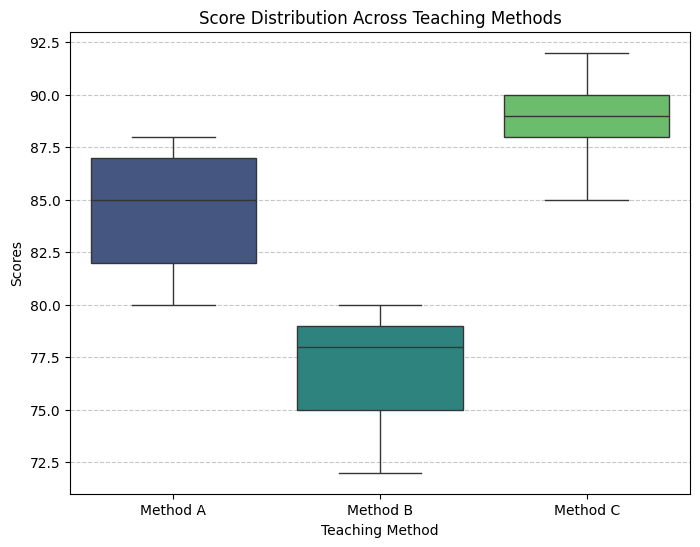

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting
data = {
    'Score': list(method_a_scores) + list(method_b_scores) + list(method_c_scores),
    'Method': ['Method A'] * len(method_a_scores) +
              ['Method B'] * len(method_b_scores) +
              ['Method C'] * len(method_c_scores)
}

df_methods = pd.DataFrame(data)

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Method', y='Score', data=df_methods, palette='viridis', hue='Method', legend=False)
plt.title('Score Distribution Across Teaching Methods')
plt.xlabel('Teaching Method')
plt.ylabel('Scores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [22]:
print(df_methods.groupby('Method')['Score'].describe())

          count  mean       std   min   25%   50%   75%   max
Method                                                       
Method A    5.0  84.4  3.361547  80.0  82.0  85.0  87.0  88.0
Method B    5.0  76.8  3.271085  72.0  75.0  78.0  79.0  80.0
Method C    5.0  88.8  2.588436  85.0  88.0  89.0  90.0  92.0


A Pattern to remember

These four problems are really testing whether you can identify the measurement level and number of groups:

Two categorical variables
->Chi-square test of independence

One continuous sample vs. one known/hypothesized value
-> One-sample t-test

Continuous outcome + two independent groups
-> Independent-samples t-test

Continuous outcome + three or more independent groups
-> One-way ANOVA